In [434]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [435]:
df_cdmx1 = pd.read_csv('./data/CDMX_2015_2020.csv')
df_cdmx2 = pd.read_csv('./data/CDMX_2020_2025.csv')

df_cuerna1 = pd.read_csv('./data/CUERNA_2015_2020.csv')
df_cuerna2 = pd.read_csv('./data/CUERNA_2020_2025.csv')

df_puebla1 = pd.read_csv('./data/PUEBLA_2015_2020.csv')
df_puebla2 = pd.read_csv('./data/PUEBLA_2020_2025.csv')

In [436]:
df_cdmx1 = df_cdmx1[df_cdmx1['DATE'] < '2020-01-01']
df_cuerna1 = df_cuerna1[df_cuerna1['DATE'] < '2020-01-01']
df_puebla1 = df_puebla1[df_puebla1['DATE'] < '2020-01-01']

In [437]:
df_general = pd.concat([df_cdmx1, df_cdmx2,
                        df_cuerna1, df_puebla1,
                        df_puebla1, df_puebla2]).sort_values(by = 'DATE')

In [438]:
df_general = df_general.reset_index(drop = True)

In [439]:
df_general.drop(['TMAX_ATTRIBUTES', 'TMIN_ATTRIBUTES'], axis = 1, inplace = True)

In [440]:
df_general['TMAX'] = (df_general['TMAX'] - 32)/1.8
df_general['TMIN'] = (df_general['TMIN'] - 32)/1.8

In [441]:
df_general['YEAR'] = df_general['DATE'].apply(lambda date: date.split(sep = '-')[0])
df_general['MONTH'] = df_general['DATE'].apply(lambda date: date.split(sep = '-')[1])
df_general['DAY'] = df_general['DATE'].apply(lambda date: date.split(sep = '-')[2])

In [442]:
df_general.dropna(axis = 0, inplace = True)

In [443]:
df_general

,STATION,NAME,DATE,TMAX,TMIN,YEAR,MONTH,DAY
0,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2015-01-01,23.888889,4.444444,2015,01,01
1,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2015-01-01,23.888889,4.444444,2015,01,01
5,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2015-01-02,22.222222,4.444444,2015,01,02
6,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2015-01-02,22.222222,4.444444,2015,01,02
9,MXM00076726,"CUERNAVACA, MX",2015-01-02,27.222222,12.777778,2015,01,02
...,...,...,...,...,...,...,...,...
16445,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2025-11-27,22.222222,10.555556,2025,11,27
16446,MXM00076680,"MEXICO CITY, MX",2025-11-28,17.777778,11.111111,2025,11,28
16447,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2025-11-28,21.111111,8.888889,2025,11,28
16448,MXM00076683,"TLAXCALA DE XICONTECATL DGE, MX",2025-11-29,21.111111,6.666667,2025,11,29


In [444]:
df_general_tmin = df_general.drop(['TMAX'], axis = 1)
df_general_tmax = df_general.drop(['TMIN'], axis = 1)

In [445]:
df_tmax = df_general_tmax.groupby(['YEAR', 'MONTH', 'DAY'])
df_tmin = df_general_tmin.groupby(['YEAR', 'MONTH', 'DAY'])

In [461]:
def per_year():
    years = [str(y) for y in range(2015, 2026, 1)]

    fig, ax = plt.subplots(len(years), 1, figsize = (16, 40))

    for i in range(len(years)):
        year = years[i]
        tmax = np.array(df_tmax.max().loc[year]['TMAX'])
        tmin = np.array(df_tmin.max().loc[year]['TMIN'])

        locs = np.linspace(0, len(tmax), 12)
        text = ['Ene', 'Feb', 'Mar', 'May', 'Abr', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov',    'Dic']

        ax[i].plot(tmin, label = '$T_{min}$')
        ax[i].plot(tmax, label = '$T_{max}$')
        ax[i].grid(alpha = 0.3)
        ax[i].legend()

        ax[i].set_title(year)

In [471]:
def yearly_avg():
    years = [str(y) for y in range(2015, 2026, 1)]
    tmax_avg = []
    tmin_avg = []

    for i in range(len(years)):
        year = years[i]
        tmax = np.array(df_tmax.max().loc[year]['TMAX'])
        tmin = np.array(df_tmin.max().loc[year]['TMIN'])
        tmax_avg.append(tmax.mean())
        tmin_avg.append(tmin.mean())

    flag = int(input("Choose: \n"
          "[1] for bar graph \n"
          "[2] for line graph \n"))
    if flag == 1:
        plt.bar(years, tmax_avg, label = '$T_{max}$')
        plt.bar(years, tmin_avg, label = '$T_{min}$')
        plt.xticks(years)
        plt.ylabel('T [°C]')
        plt.legend()
        plt.show()
    elif flag == 2:
        plt.plot(years, tmax_avg, label = '$T_{max}$')
        plt.plot(years, tmin_avg, label = '$T_{min}$')
        plt.xticks(years)
        plt.ylabel('T [°C]')
        plt.legend()
        plt.show()
    else:
        print("Invalid choice")

In [ ]:
def records():


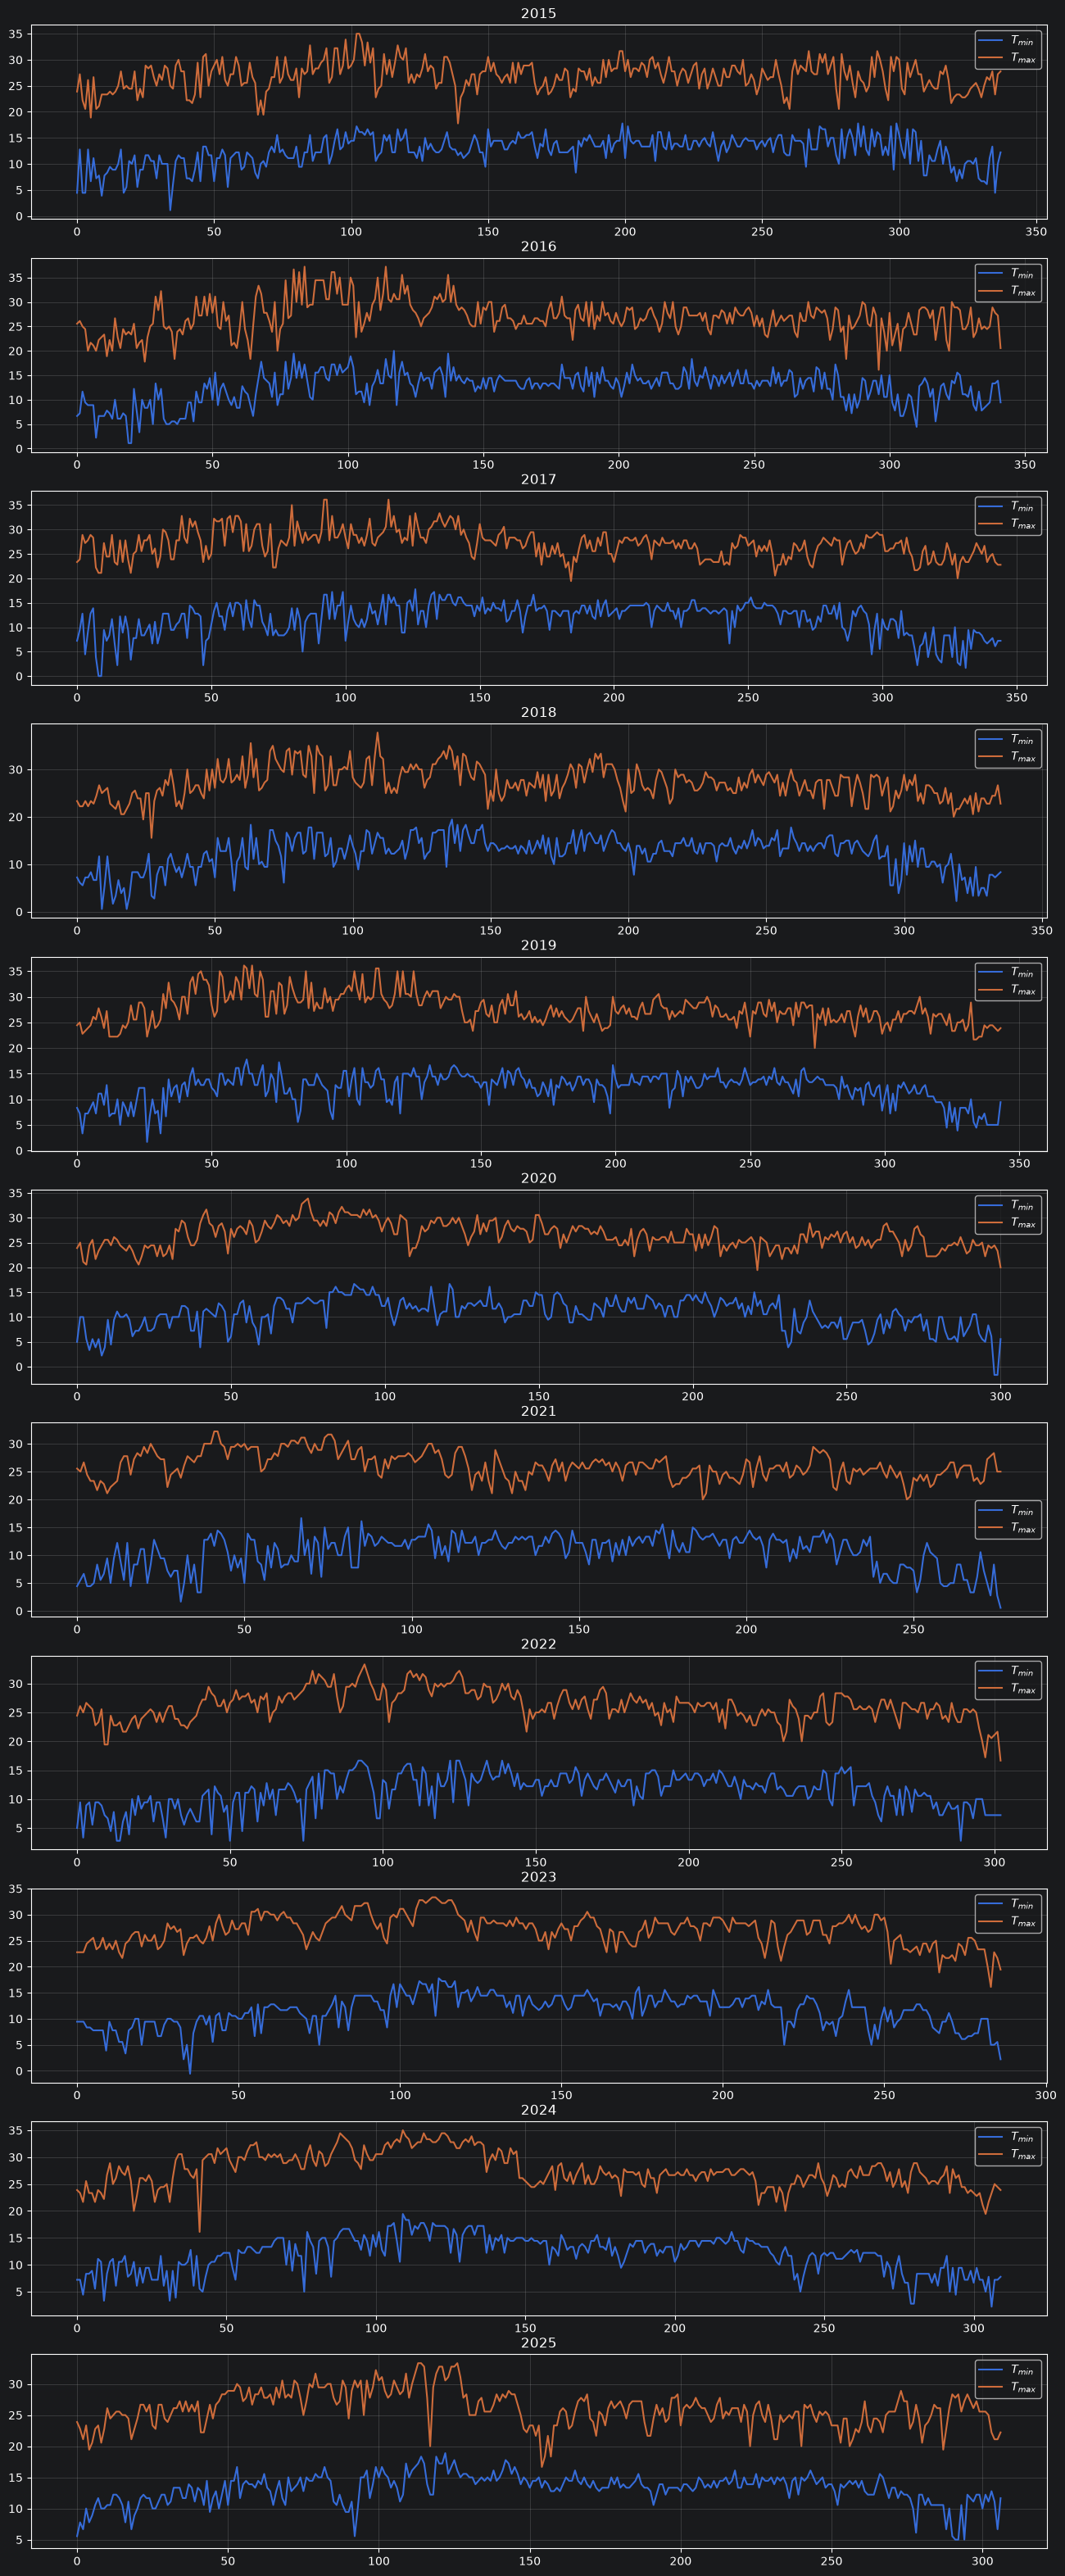

In [462]:
per_year()

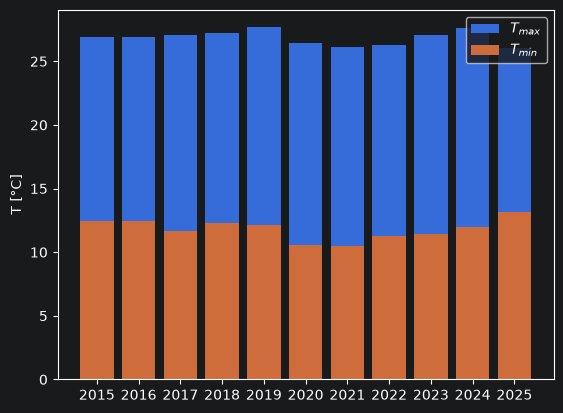

In [472]:
yearly_avg()